In [26]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

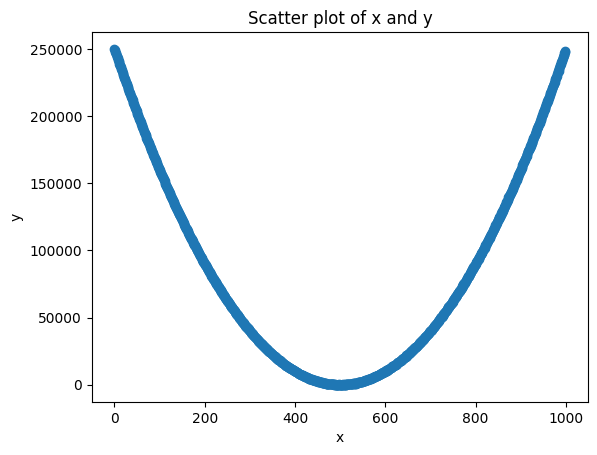

In [27]:
x = list(range(1000))
#y = [2*i + np.random.normal(0, i/4) for i in x]
y = [(i-500)**2 + np.random.normal(0, i/4) for i in x]

df = pd.DataFrame({'x': x, 'y': y})
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
plt.show()

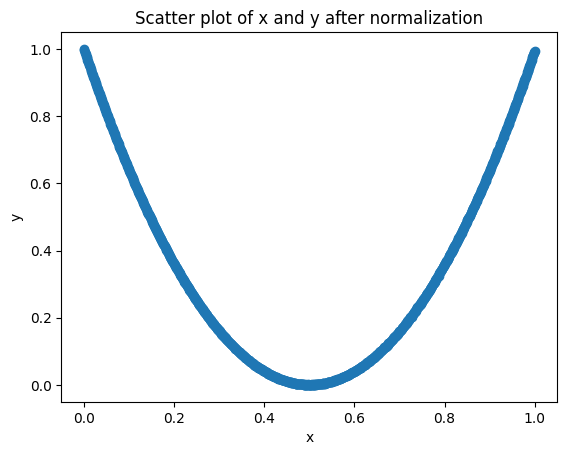

In [28]:
# normalize the data min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after normalization')
plt.show()

In [29]:
x_train = df[['x', 'y']].values
x_train.shape

(1000, 2)

In [30]:
x_train

array([[0.        , 1.        ],
       [0.001001  , 0.99600637],
       [0.002002  , 0.99202184],
       ...,
       [0.997998  , 0.98876678],
       [0.998999  , 0.99199795],
       [1.        , 0.99528074]])

In [31]:
import keras

In [32]:
input_shape = (2,)
encoder = keras.models.Sequential([keras.layers.Dense(1)]) 
# if activaton is not defined, it is linear by default
decoder = keras.models.Sequential([keras.layers.Dense(input_shape[0])])

autoencoder = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        encoder, 
        decoder
])
autoencoder.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 2)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.01))
history = autoencoder.fit(x_train, x_train, epochs=20)
codings = encoder.predict(x_train)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4317  
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2135 
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1456 
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1346 
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1135 
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1057 
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0989 
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0868 
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0827 
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0818 
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0704 
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0746 
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0672 
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0649 
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0628 
Epo

In [34]:
T = codings
T.shape
T

array([[-1.4134092 ],
       [-1.408364  ],
       [-1.4033291 ],
       [-1.3983015 ],
       [-1.3932751 ],
       [-1.3882719 ],
       [-1.383279  ],
       [-1.3782816 ],
       [-1.3733045 ],
       [-1.3683194 ],
       [-1.3633786 ],
       [-1.3584065 ],
       [-1.3534778 ],
       [-1.3485432 ],
       [-1.3436106 ],
       [-1.3386886 ],
       [-1.3338046 ],
       [-1.3289317 ],
       [-1.3240218 ],
       [-1.3191121 ],
       [-1.3142166 ],
       [-1.3093892 ],
       [-1.3044986 ],
       [-1.2996625 ],
       [-1.2948871 ],
       [-1.290018  ],
       [-1.285229  ],
       [-1.280389  ],
       [-1.2755665 ],
       [-1.2708259 ],
       [-1.266042  ],
       [-1.2612966 ],
       [-1.2564821 ],
       [-1.2517431 ],
       [-1.246974  ],
       [-1.2422419 ],
       [-1.23752   ],
       [-1.2327936 ],
       [-1.22813   ],
       [-1.223428  ],
       [-1.2187786 ],
       [-1.2140646 ],
       [-1.2093558 ],
       [-1.2046964 ],
       [-1.2001029 ],
       [-1

In [35]:
newdf = decoder.predict(T)
newdf

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[0.5731818 , 1.1057005 ],
       [0.5727119 , 1.1018761 ],
       [0.5722429 , 1.0980595 ],
       ...,
       [0.52571225, 0.71938896],
       [0.5260085 , 0.72179985],
       [0.5263102 , 0.7242552 ]], dtype=float32)

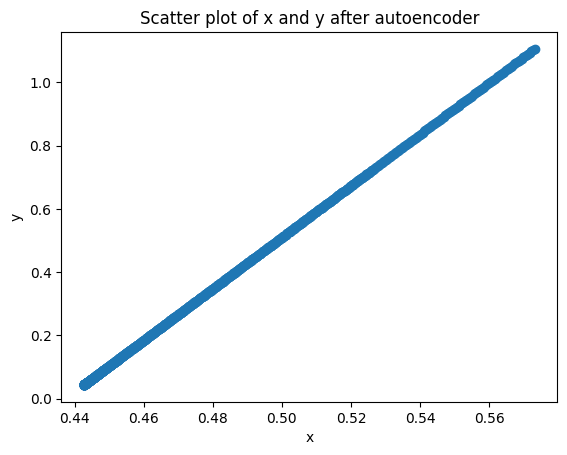

In [36]:
plt.scatter(newdf[:, 0], newdf[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after autoencoder')
plt.show()